In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from sarima import plot_target

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


C:\Users\Jojie\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv('Updated Data/disaggregated_recent.csv')
first_col = df.columns[0]
df[first_col] = pd.to_datetime(df[first_col], errors='coerce')
df = df.rename(columns={"Unnamed: 3": "Date"})
df.set_index("Date", inplace=True)

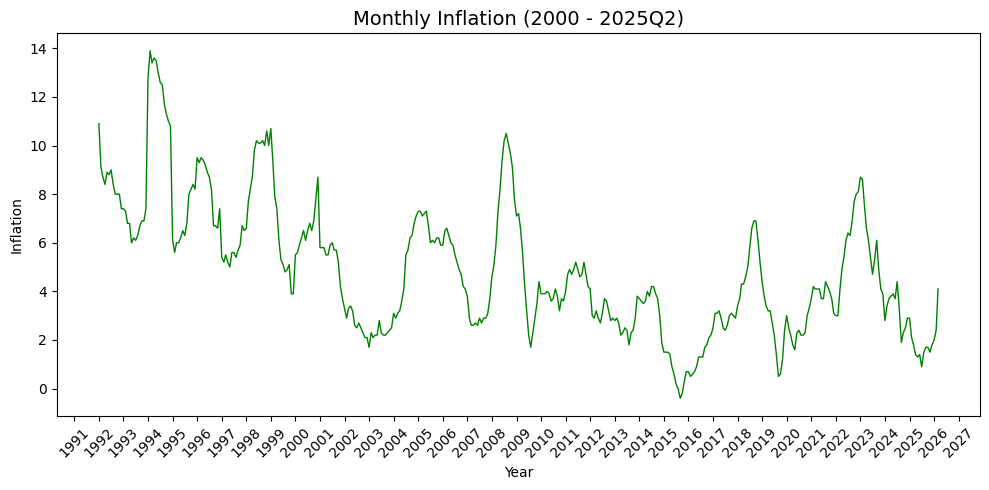

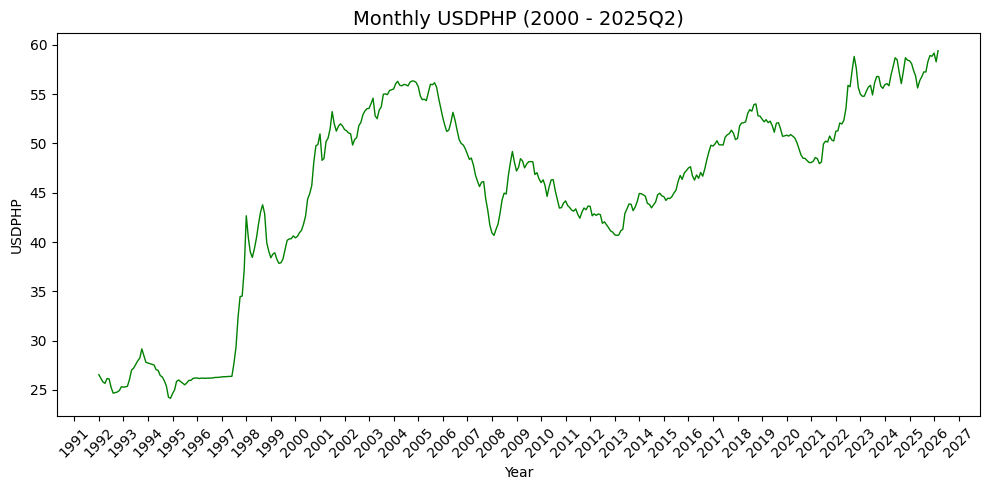

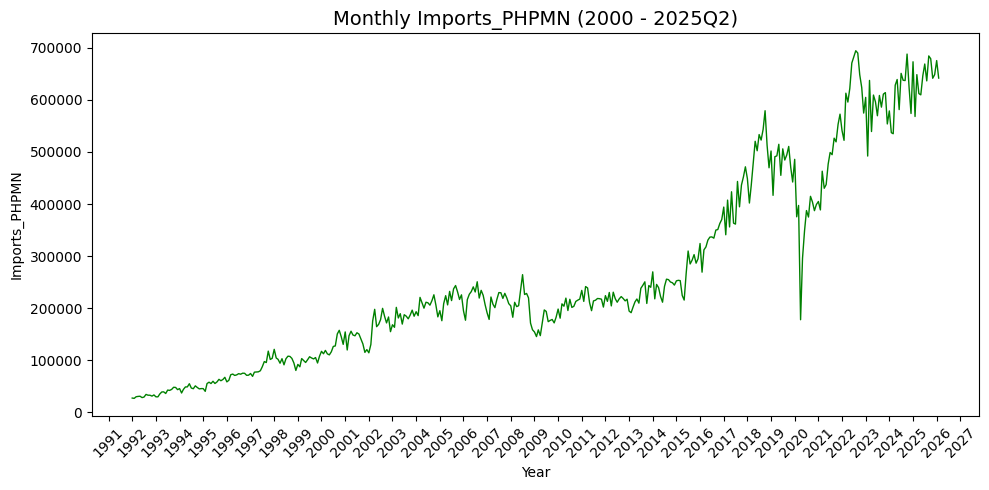

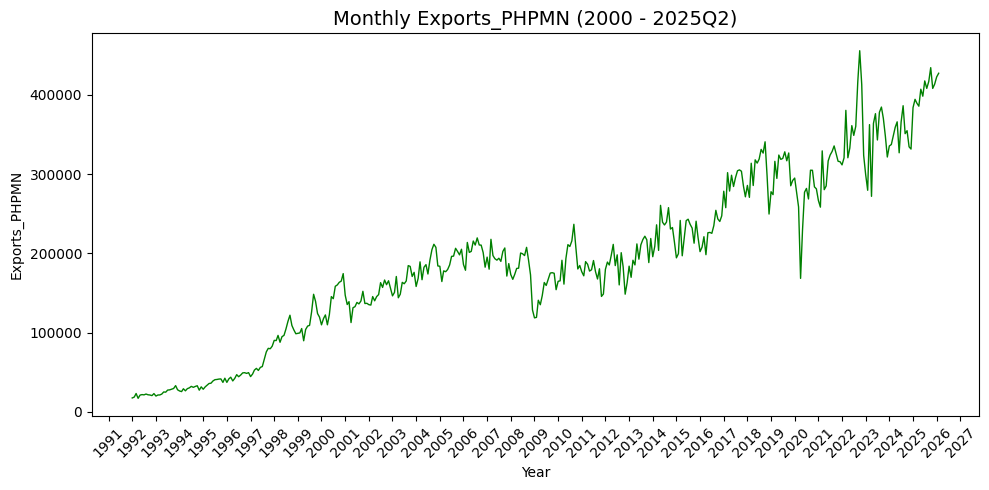

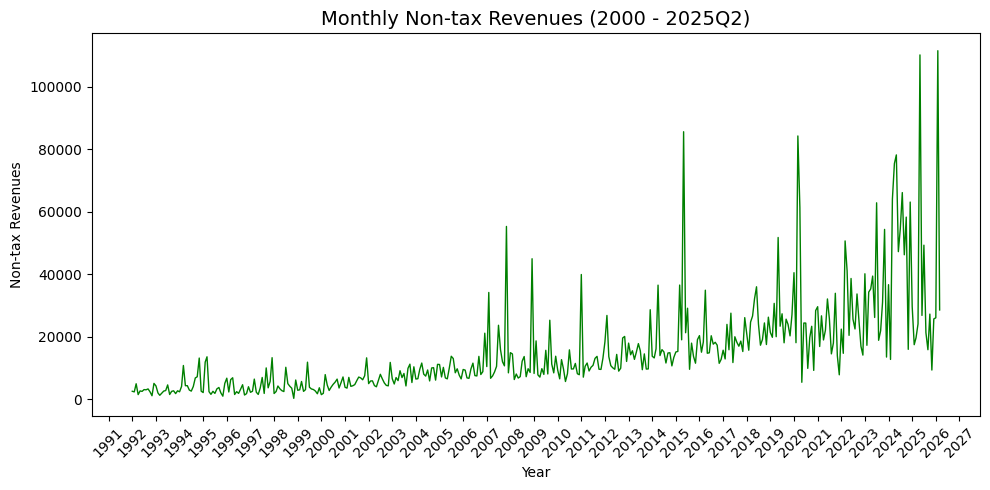

In [14]:
import importlib
import sarima
importlib.reload(sarima)
from sarima import plot_target

cols = ["Inflation", "USDPHP", "Imports_PHPMN", "Exports_PHPMN","Non-tax Revenues"]
test_num = int(len(df) * 0.20)
train_size = len(df) - test_num

train = df.iloc[:train_size][cols].reset_index().copy()
test = df.iloc[train_size:][cols].reset_index().copy()

train_plot = train.set_index("Date")
test_plot = test.set_index("Date")

for col in cols:
    plot_target(df, col, color="green")

In [7]:
LABEL_COLS = ["Inflation", "USDPHP", "Imports_PHPMN", "Exports_PHPMN", "Non-tax Revenues"]

records = []

for x in LABEL_COLS:
    s = pd.to_numeric(train[x], errors="coerce")

    level = adfuller(s.dropna(), autolag="AIC")
    first_diff = adfuller(s.diff().dropna(), autolag="AIC")
    second_diff = adfuller(s.diff().diff().dropna(), autolag="AIC")
    seasonal_diff = adfuller(s.diff(12).dropna(), autolag="AIC")
    seasonal_double_diff = adfuller(s.diff().diff(12).dropna(), autolag="AIC")

    records.append({
        "Variable": x,
        "Level p-value": round(level[1], 4),
        "Level Stationary": level[1] < 0.05,
        "First Diff p-value": round(first_diff[1], 4),
        "First Diff Stationary": first_diff[1] < 0.05,
        "Second Diff p-value": round(second_diff[1], 4),
        "Second Diff Stationary": second_diff[1] < 0.05,
        "Seasonal Diff p-value": round(seasonal_diff[1], 4),
        "Seasonal Diff Stationary": seasonal_diff[1] < 0.05,
        "Seasonal Double Diff p-value": round(seasonal_double_diff[1], 4),
        "Seasonal Double Diff Stationary": seasonal_double_diff[1] < 0.05,
    })

stationarity_df = pd.DataFrame(records).set_index("Variable")
stationarity_df

,Level p-value,Level Stationary,First Diff p-value,First Diff Stationary,Second Diff p-value,Second Diff Stationary,Seasonal Diff p-value,Seasonal Diff Stationary,Seasonal Double Diff p-value,Seasonal Double Diff Stationary
Variable,,,,,,,,,,
Inflation,0.1860,False,0.0,True,0.0,True,0.0000,True,0.0,True
USDPHP,0.4271,False,0.0,True,0.0,True,0.0170,True,0.0,True
Imports_PHPMN,0.8520,False,0.0,True,0.0,True,0.0000,True,0.0,True
Exports_PHPMN,0.8258,False,0.0,True,0.0,True,0.0005,True,0.0,True
Non-tax Revenues,0.9468,False,0.0,True,0.0,True,0.0000,True,0.0,True


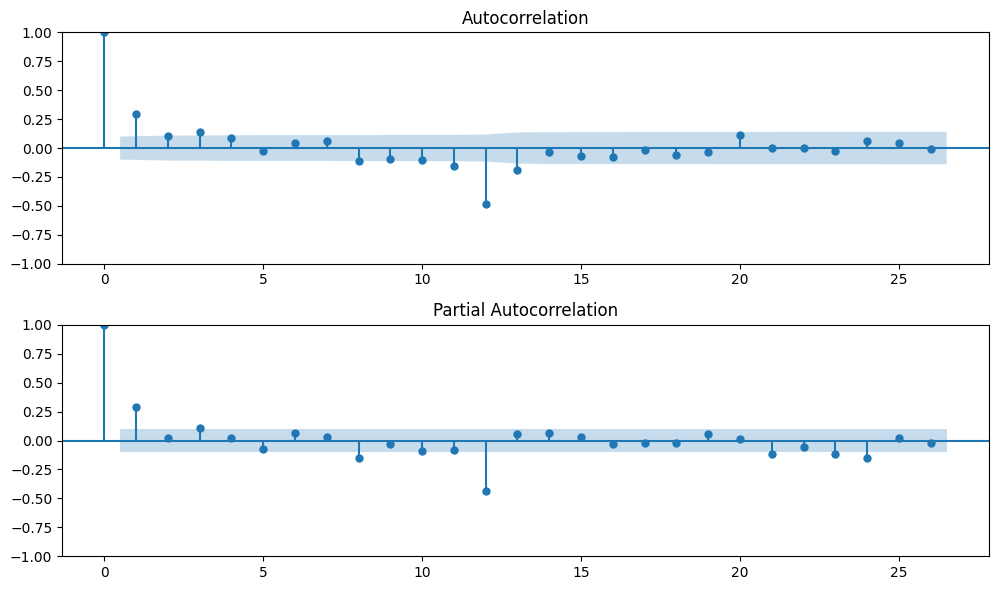

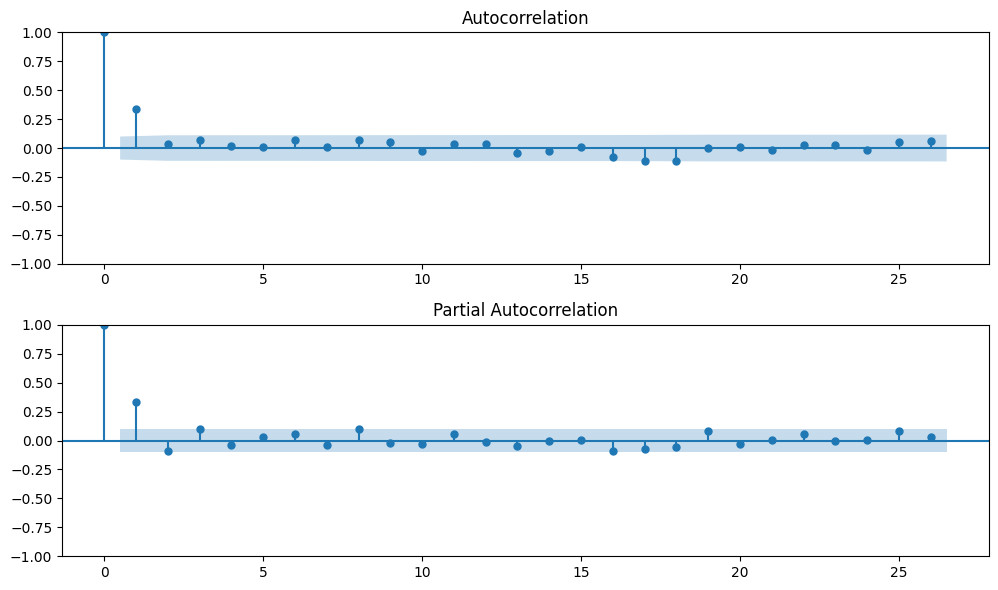

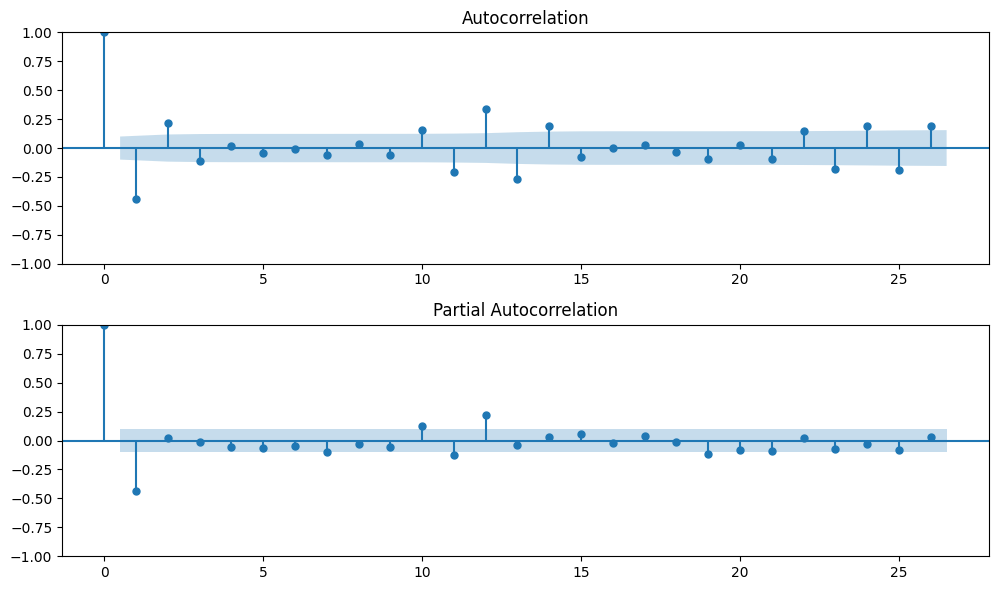

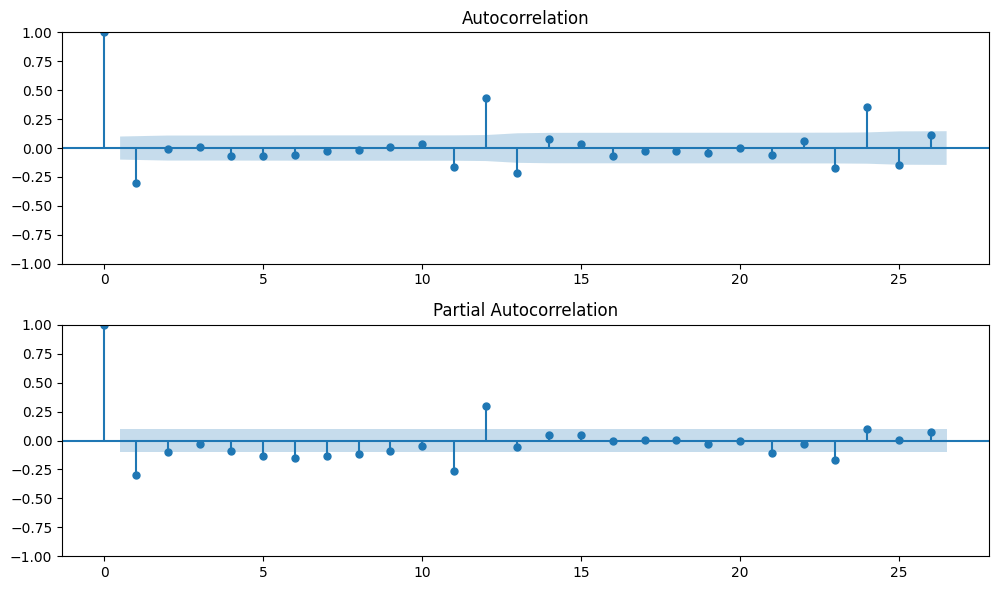

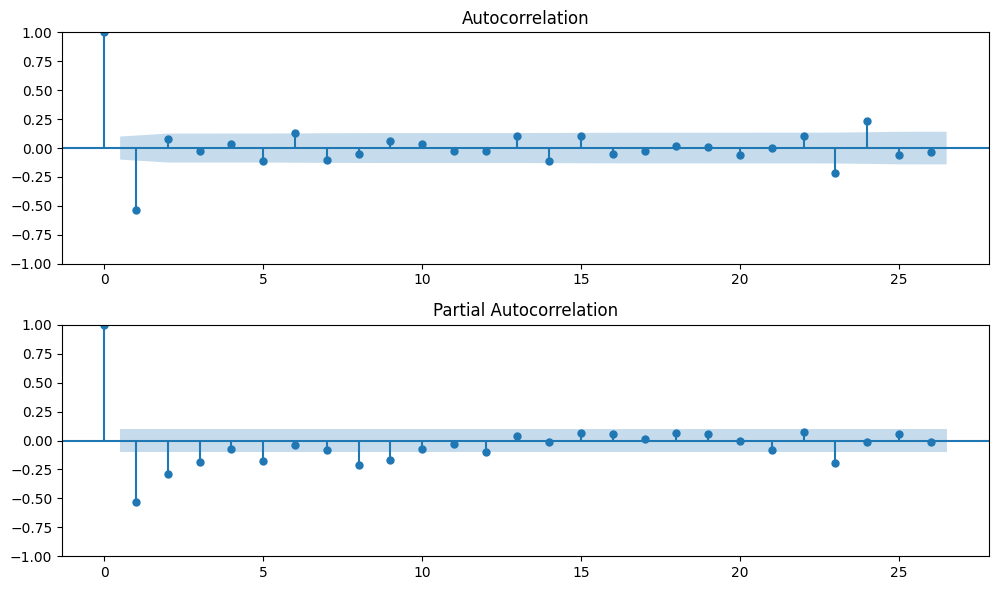

In [10]:
diff_inflation = pd.to_numeric(train["Inflation"], errors="coerce").diff().dropna()
diff_usdphp = pd.to_numeric(train["USDPHP"], errors="coerce").diff().dropna()
diff_imports = pd.to_numeric(train["Imports_PHPMN"], errors="coerce").diff().dropna()
diff_exports = pd.to_numeric(train["Exports_PHPMN"], errors="coerce").diff().dropna()
diff_nontax = pd.to_numeric(train["Non-tax Revenues"], errors="coerce").diff().dropna()

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(diff_inflation.dropna(), ax=ax[0])
plot_pacf(diff_inflation.dropna(), ax=ax[1])
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(diff_usdphp.dropna(), ax=ax[0])
plot_pacf(diff_usdphp.dropna(), ax=ax[1])
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(diff_imports.dropna(), ax=ax[0])
plot_pacf(diff_imports.dropna(), ax=ax[1])
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(diff_exports.dropna(), ax=ax[0])
plot_pacf(diff_exports.dropna(), ax=ax[1])
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(diff_nontax.dropna(), ax=ax[0])
plot_pacf(diff_nontax.dropna(), ax=ax[1])
plt.tight_layout()
plt.show()

## Population

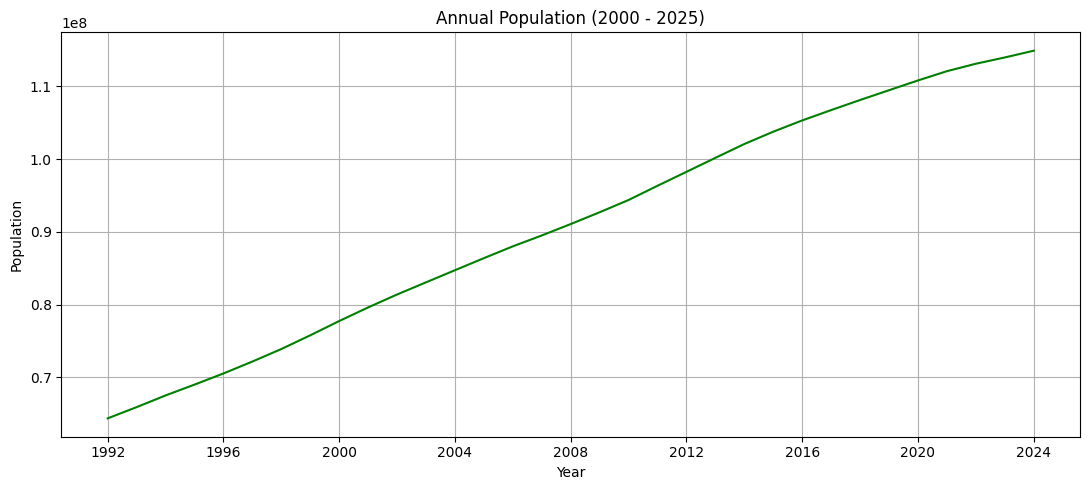

In [6]:
cols = ["Population"]

use_cols = [c for c in cols if c in df.columns]
if not use_cols:
    raise ValueError("Requested columns are not present in df.")

df_clean = df[use_cols].dropna(subset=["Population"]).copy()
if df_clean.empty:
    raise ValueError("No rows left after dropping NaN values in Population.")

# Population is treated as annual data.
df_clean.index = pd.to_datetime(df_clean.index).to_period("Y").to_timestamp()
df_clean = df_clean.groupby(df_clean.index).last().sort_index()

test_num = int(len(df_clean) * 0.20)
train_size = len(df_clean) - test_num

train = df_clean.iloc[:train_size].reset_index().copy()
test = df_clean.iloc[train_size:].reset_index().copy()
train = train.rename(columns={"index": "Date"})
test = test.rename(columns={"index": "Date"})

train_plot = train.set_index("Date")
test_plot = test.set_index("Date")

for col in use_cols:
    plt.figure(figsize=(11, 5))
    plt.plot(df_clean.index, df_clean[col], color="green", linewidth=1.5)
    plt.title(f"Annual {col} (2000 - 2025)")
    plt.xlabel("Year")
    plt.ylabel(col)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [7]:
LABEL_COLS = ["Population"]

records = []

for x in LABEL_COLS:
    s = pd.to_numeric(train[x], errors="coerce")

    level = adfuller(s.dropna(), autolag="AIC")
    first_diff = adfuller(s.diff().dropna(), autolag="AIC")
    second_diff = adfuller(s.diff().diff().dropna(), autolag="AIC")
    seasonal_diff = adfuller(s.diff(12).dropna(), autolag="AIC")
    seasonal_double_diff = adfuller(s.diff().diff(12).dropna(), autolag="AIC")

    records.append({
        "Variable": x,
        "Level p-value": round(level[1], 4),
        "Level Stationary": level[1] < 0.05,
        "First Diff p-value": round(first_diff[1], 4),
        "First Diff Stationary": first_diff[1] < 0.05,
        "Second Diff p-value": round(second_diff[1], 4),
        "Second Diff Stationary": second_diff[1] < 0.05,
        "Seasonal Diff p-value": round(seasonal_diff[1], 4),
        "Seasonal Diff Stationary": seasonal_diff[1] < 0.05,
        "Seasonal Double Diff p-value": round(seasonal_double_diff[1], 4),
        "Seasonal Double Diff Stationary": seasonal_double_diff[1] < 0.05,
    })

stationarity_df = pd.DataFrame(records).set_index("Variable")
stationarity_df

,Level p-value,Level Stationary,First Diff p-value,First Diff Stationary,Second Diff p-value,Second Diff Stationary,Seasonal Diff p-value,Seasonal Diff Stationary,Seasonal Double Diff p-value,Seasonal Double Diff Stationary
Variable,,,,,,,,,,
Population,0.9319,False,0.034,True,0.0193,True,0.6512,False,0.2142,False


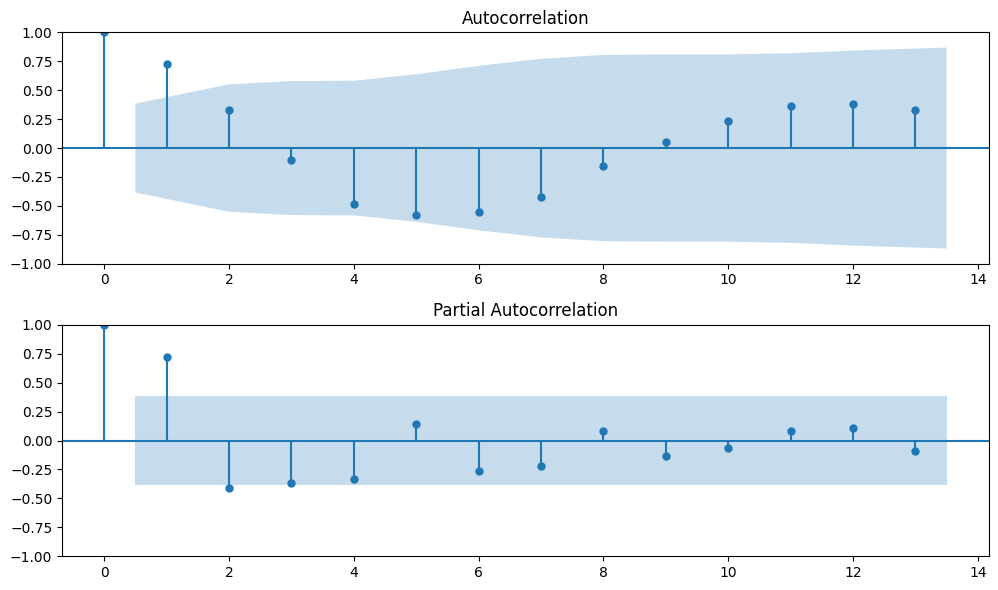

In [8]:
diff_population = train["Population"].diff().dropna()

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(diff_population.dropna(), ax=ax[0])
plot_pacf(diff_population.dropna(), ax=ax[1])
plt.tight_layout()
plt.show()

## Quarterly GDP

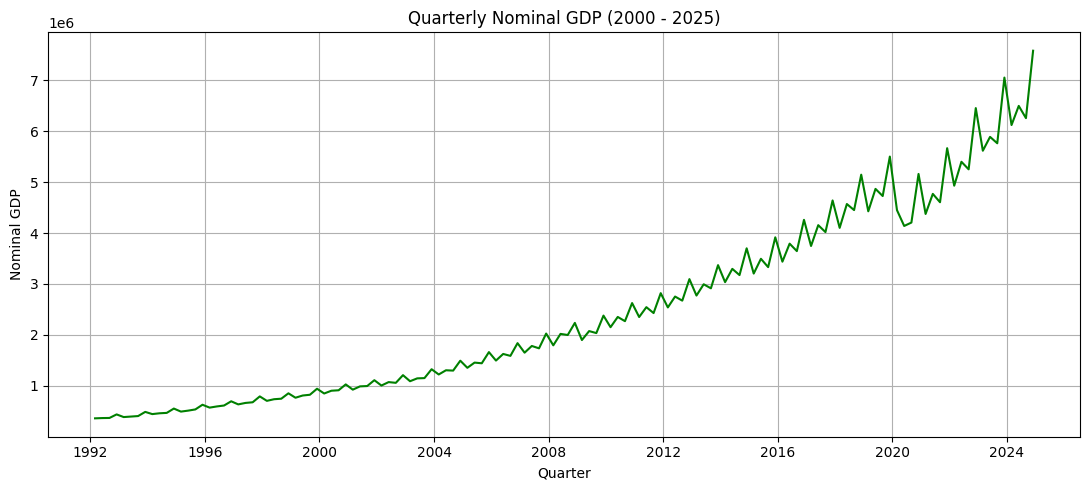

In [9]:
cols = ["Nominal GDP"]

use_cols = [c for c in cols if c in df.columns]
if not use_cols:
    raise ValueError("Requested columns are not present in df.")

df_clean = df[use_cols].copy()
df_clean["Nominal GDP"] = pd.to_numeric(df_clean["Nominal GDP"], errors="coerce")
df_clean = df_clean.dropna(subset=["Nominal GDP"])
if df_clean.empty:
    raise ValueError("No rows left after dropping NaN values in Nominal GDP.")

# Anchor quarterly dates to the first day of the quarter-ending month: Mar, Jun, Sep, Dec.
quarter_index = pd.to_datetime(df_clean.index).to_period("Q")
df_clean.index = quarter_index.asfreq("M", how="end").to_timestamp()
df_clean = df_clean.groupby(df_clean.index).last().sort_index().asfreq("QS-MAR")
df_clean = df_clean.ffill().bfill()

test_num = int(len(df_clean) * 0.20)
train_size = len(df_clean) - test_num

train = df_clean.iloc[:train_size].reset_index().copy()
test = df_clean.iloc[train_size:].reset_index().copy()
train = train.rename(columns={"index": "Date"})
test = test.rename(columns={"index": "Date"})

train_plot = train.set_index("Date")
test_plot = test.set_index("Date")

for col in use_cols:
    plt.figure(figsize=(11, 5))
    plt.plot(df_clean.index, df_clean[col], color="green", linewidth=1.5)
    plt.title(f"Quarterly {col} (2000 - 2025)")
    plt.xlabel("Quarter")
    plt.ylabel(col)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [10]:
LABEL_COLS = ["Nominal GDP"]

records = []

for x in LABEL_COLS:
    s = pd.to_numeric(train[x], errors="coerce")

    level = adfuller(s.dropna(), autolag="AIC")
    first_diff = adfuller(s.diff().dropna(), autolag="AIC")
    second_diff = adfuller(s.diff().diff().dropna(), autolag="AIC")
    seasonal_diff = adfuller(s.diff(12).dropna(), autolag="AIC")
    seasonal_double_diff = adfuller(s.diff().diff(12).dropna(), autolag="AIC")

    records.append({
        "Variable": x,
        "Level p-value": round(level[1], 4),
        "Level Stationary": level[1] < 0.05,
        "First Diff p-value": round(first_diff[1], 4),
        "First Diff Stationary": first_diff[1] < 0.05,
        "Second Diff p-value": round(second_diff[1], 4),
        "Second Diff Stationary": second_diff[1] < 0.05,
        "Seasonal Diff p-value": round(seasonal_diff[1], 4),
        "Seasonal Diff Stationary": seasonal_diff[1] < 0.05,
        "Seasonal Double Diff p-value": round(seasonal_double_diff[1], 4),
        "Seasonal Double Diff Stationary": seasonal_double_diff[1] < 0.05,
    })

stationarity_df = pd.DataFrame(records).set_index("Variable")
stationarity_df

,Level p-value,Level Stationary,First Diff p-value,First Diff Stationary,Second Diff p-value,Second Diff Stationary,Seasonal Diff p-value,Seasonal Diff Stationary,Seasonal Double Diff p-value,Seasonal Double Diff Stationary
Variable,,,,,,,,,,
Nominal GDP,1.0,False,0.9822,False,0.0,True,0.9985,False,0.1871,False


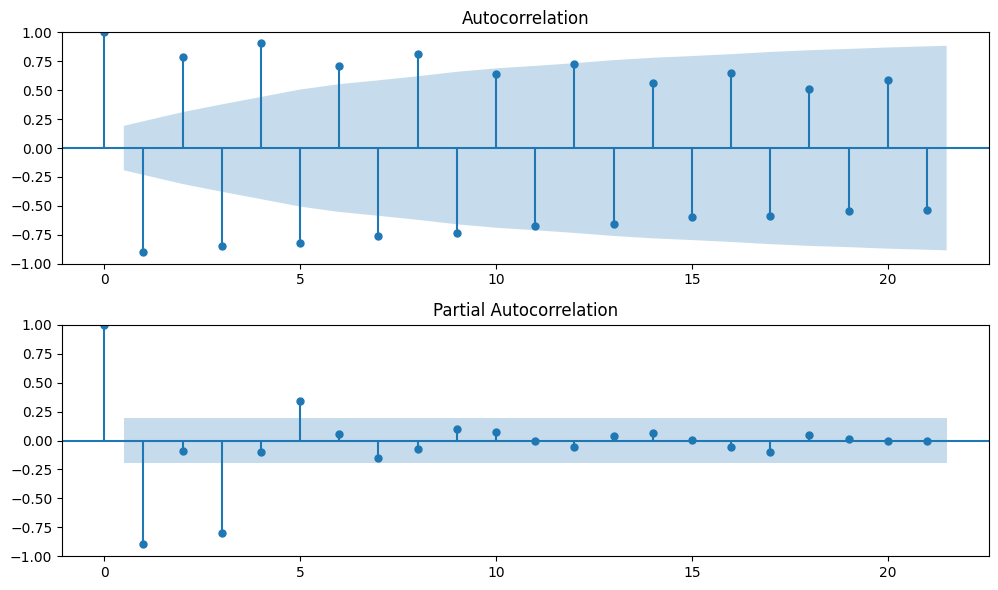

In [11]:
diff_gdp = train["Nominal GDP"].diff().diff().dropna()

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(diff_gdp, ax=ax[0])
plot_pacf(diff_gdp, ax=ax[1])
plt.tight_layout()
plt.show()

## Final

In [12]:
# Ensure Date index is datetime and unique before any asfreq/reindex operations.
df.index = pd.to_datetime(df.index, errors="coerce")
df = df[~df.index.isna()].sort_index()
dup_count = int(df.index.duplicated(keep="last").sum())
if dup_count > 0:
    print(f"Found {dup_count} duplicate Date rows. Keeping last occurrence per date.")
    df = df[~df.index.duplicated(keep="last")]
else:
    print("No duplicate Date rows found.")

No duplicate Date rows found.


Imports_PHPMN        1
Exports_PHPMN        1
Non-tax Revenues    15
dtype: int64


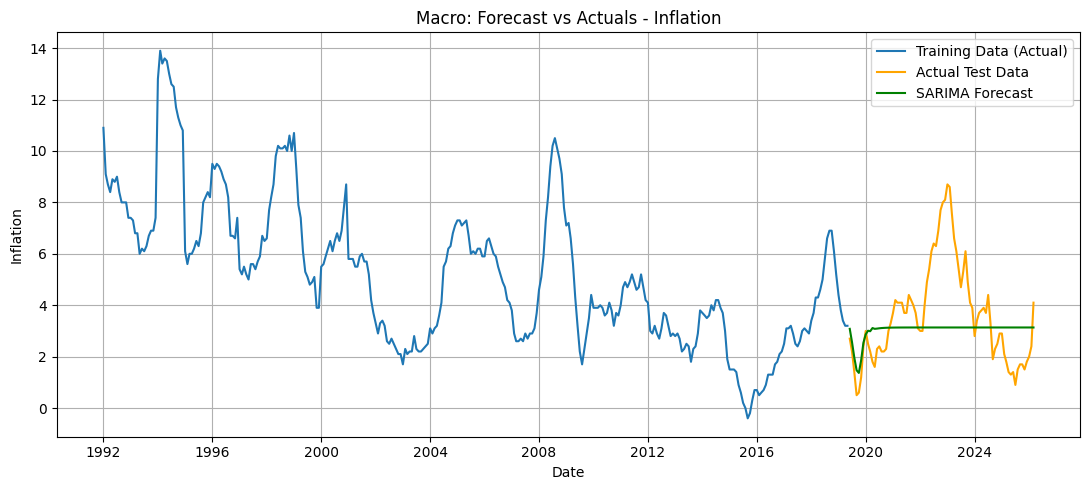

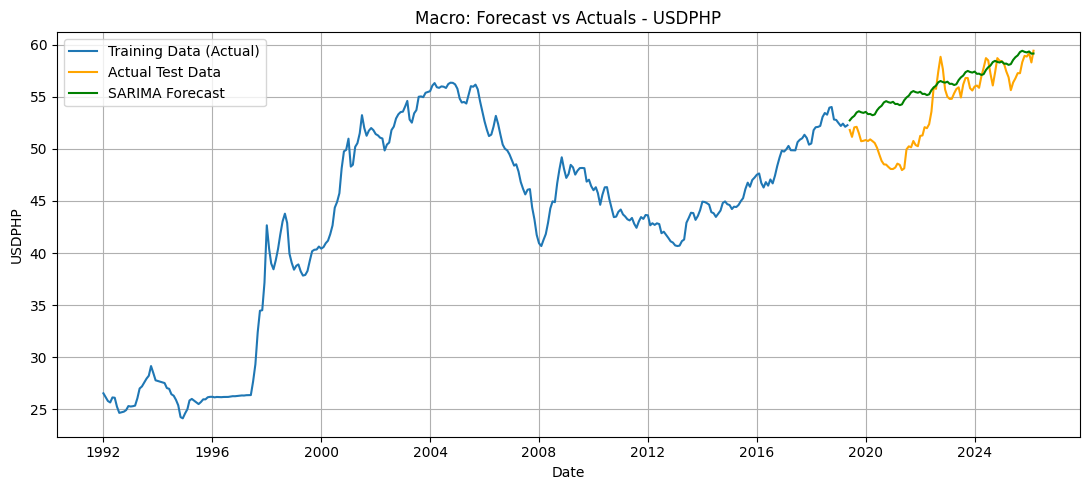

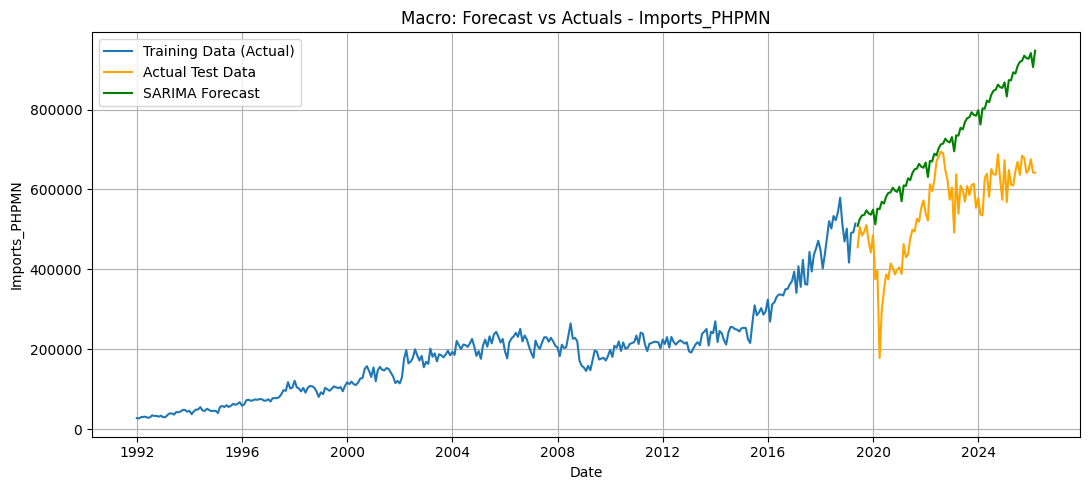

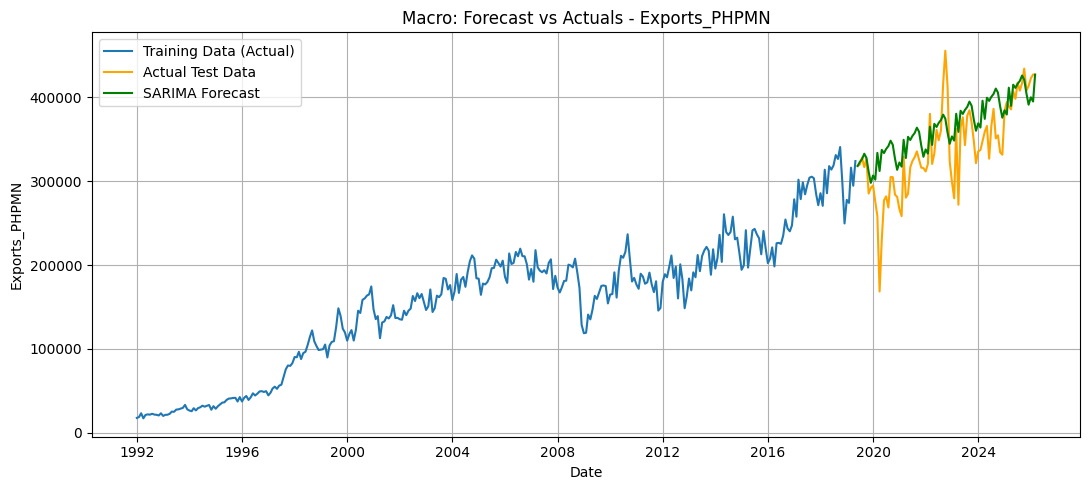

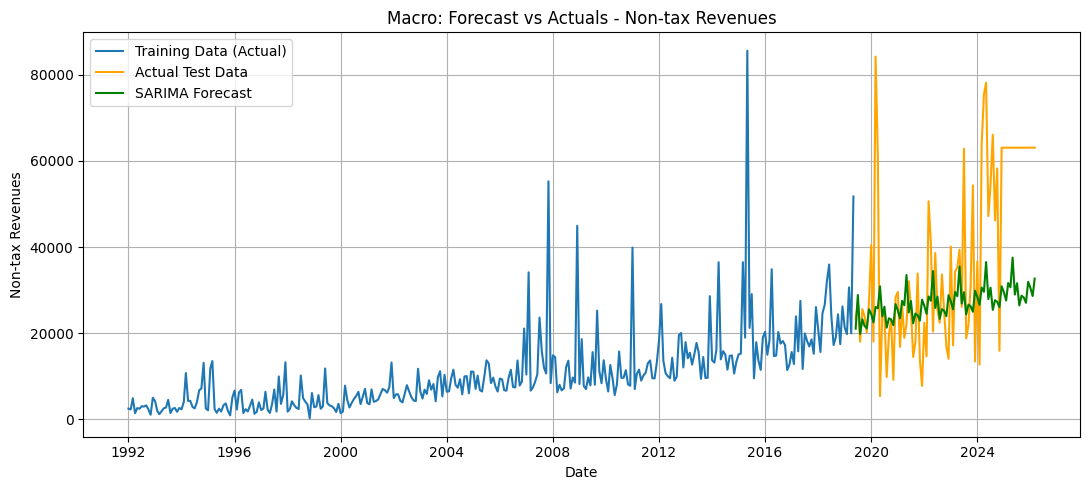

[Macro] Inflation: forecasting 12 months from 2026-04-01 to 2027-03-01
[Macro] USDPHP: forecasting 12 months from 2026-04-01 to 2027-03-01
[Macro] Imports_PHPMN: forecasting 13 months from 2026-03-01 to 2027-03-01
[Macro] Exports_PHPMN: forecasting 13 months from 2026-03-01 to 2027-03-01
[Macro] Non-tax Revenues: forecasting 27 months from 2025-01-01 to 2027-03-01
[Population] Population: best order (1, 1, 1), AIC=630.52


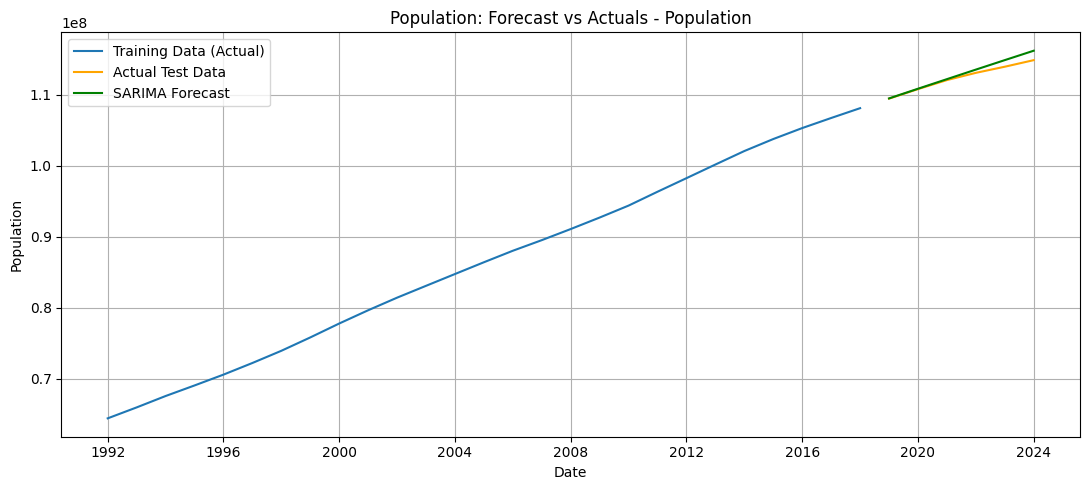

[Population] Population: forecasting 3 years from 2025-01-01 to 2027-01-01


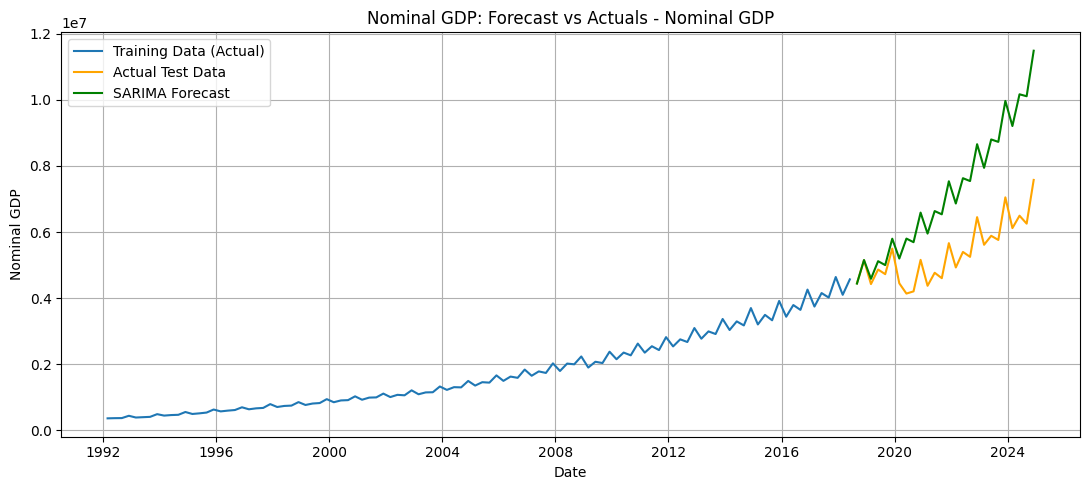

[GDP] Nominal GDP: forecasting 10 quarters from 2024-12-01 to 2027-03-01


n_obs           MAE          RMSE   MAPE_pct  \
Section     Variable                                                         
Macro       Inflation            82  1.427810e+00  1.932504e+00  45.471250   
            USDPHP               82  2.391359e+00  3.092422e+00   4.676374   
            Imports_PHPMN        82  1.703589e+05  1.880169e+05  33.666070   
            Exports_PHPMN        82  3.188493e+04  4.113852e+04  10.596962   
            Non-tax Revenues     82  1.623497e+04  2.143076e+04  47.966439   
Population  Population            6  4.885152e+05  6.909699e+05   0.428314   
Nominal GDP Nominal GDP          26  1.842846e+06  2.187091e+06  32.830466   

                              sMAPE_pct  Mean_Error(actual-forecast)  
Section     Variable                                                  
Macro       Inflation         40.955098                 5.675105e-01  
            USDPHP             4.496577                -2.199316e+00  
            Imports_PHPMN     27.328539                -1.703589e+05  
            Exports_PHPMN      9.642547                -2.454374e+04  
            Non-tax Revenues  45.136830                 1.016087e+04  
Population  Population         0.426501                -4.885152e+05  
Nominal GDP Nominal GDP       27.067026                -1.842109e+06

,Inflation,USDPHP,Imports_PHPMN,Exports_PHPMN,Non-tax Revenues,Population,Nominal GDP
Date,,,,,,,
2025-01-01,2.900000,58.390600,673137.347100,383832.944700,75598.311767,1.158070e+08,NaN
2025-02-01,2.100000,58.094200,568074.715600,394295.211400,72089.649556,NaN,NaN
2025-03-01,1.800000,57.424600,648447.771100,389493.260200,66735.251852,NaN,6.816423e+06
2025-04-01,1.400000,56.852900,612085.712300,385653.119200,71232.656029,NaN,NaN
2025-05-01,1.300000,55.624600,609636.716100,407076.397700,62218.096800,NaN,NaN
2025-06-01,1.400000,56.358600,646137.822900,398251.847500,62768.721786,NaN,6.534055e+06
2025-07-01,0.900000,56.752300,668863.312000,417539.724100,66959.131978,NaN,NaN
2025-08-01,1.500000,57.252500,636466.309600,408094.102400,57970.296139,NaN,NaN
2025-09-01,1.700000,57.250100,684379.717900,416868.893200,63139.654340,NaN,7.920645e+06


In [15]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product as iproduct
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sarima import multitarget_sarima


def _parse_order(x):
    return ast.literal_eval(x) if isinstance(x, str) else x


def _future_index_from(last_obs_date, end_date, freq):
    """Return a date_range starting from the first period after last_obs_date."""
    start = last_obs_date + {"MS": pd.offsets.MonthBegin(1),
                              "YS": pd.offsets.YearBegin(1),
                              "QS-MAR": pd.offsets.QuarterBegin(startingMonth=3)}[freq]
    idx = pd.date_range(start, end_date, freq=freq)
    return idx


def _fit_test_forecasts(train_df, test_df, best_df, label_list):
    out = pd.DataFrame(index=pd.to_datetime(test_df.index))
    for lbl in label_list:
        order = tuple(_parse_order(best_df.loc[lbl, "Best_Order"]))
        seasonal_order = tuple(_parse_order(best_df.loc[lbl, "Best_Seasonal_Order"]))

        series = pd.to_numeric(train_df[lbl], errors="coerce").dropna()
        model = SARIMAX(series, order=order, seasonal_order=seasonal_order,
                        enforce_stationarity=False, enforce_invertibility=False)
        fit = model.fit(disp=False)
        pred = fit.get_forecast(steps=len(test_df)).predicted_mean
        out[lbl] = pred.values
    return out


def _plot_and_metrics(train_df, test_df, forecast_df, label_list, section_name):
    records = []
    train_plot = train_df.copy()
    test_plot  = test_df.copy()
    train_plot.index = pd.to_datetime(train_plot.index)
    test_plot.index  = pd.to_datetime(test_plot.index)

    for lbl in label_list:
        if lbl not in train_plot.columns or lbl not in test_plot.columns or lbl not in forecast_df.columns:
            continue

        y_train = pd.to_numeric(train_plot[lbl],  errors="coerce")
        y_test  = pd.to_numeric(test_plot[lbl],   errors="coerce")
        y_pred  = pd.to_numeric(forecast_df[lbl], errors="coerce")

        plt.figure(figsize=(11, 5))
        plt.plot(train_plot.index,  y_train, label="Training Data (Actual)")
        plt.plot(test_plot.index,   y_test,  label="Actual Test Data",  color="orange")
        plt.plot(forecast_df.index, y_pred,  label="SARIMA Forecast",   color="green")
        plt.title(f"{section_name}: Forecast vs Actuals - {lbl}")
        plt.xlabel("Date"); plt.ylabel(lbl)
        plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

        a = y_test.reset_index(drop=True)
        f = y_pred.reset_index(drop=True)
        comp = pd.concat([a, f], axis=1, keys=["actual", "forecast"]).dropna()
        if comp.empty:
            continue

        a, f  = comp["actual"], comp["forecast"]
        err   = a - f
        mae   = np.mean(np.abs(err))
        rmse  = np.sqrt(np.mean(err ** 2))

        mape = np.nan
        nz   = a != 0
        if nz.any():
            mape = np.mean(np.abs((a[nz] - f[nz]) / a[nz])) * 100

        smape = np.nan
        denom = np.abs(a) + np.abs(f)
        mask  = denom != 0
        if mask.any():
            smape = np.mean(2 * np.abs(a[mask] - f[mask]) / denom[mask]) * 100

        records.append({"Section": section_name, "Variable": lbl, "n_obs": len(comp),
                         "MAE": mae, "RMSE": rmse, "MAPE_pct": mape, "sMAPE_pct": smape,
                         "Mean_Error(actual-forecast)": err.mean()})

    return pd.DataFrame(records)


def _last_observed(df_raw, col, freq):
    """
    Return the last date in df_raw[col] that has a non-null value,
    snapped to the given frequency's period boundary.
    """
    s = pd.to_numeric(df_raw[col], errors="coerce").dropna()
    if s.empty:
        return None
    last = pd.to_datetime(s.index).max()
    return last.to_period({"MS": "M", "YS": "Y", "QS-MAR": "Q"}[freq]).to_timestamp()


FORECAST_END = "2027-3-01"

# ------------------------------
# 1) Monthly macro forecasts
# ------------------------------
macro_labels = ["Inflation", "USDPHP", "Imports_PHPMN", "Exports_PHPMN", "Non-tax Revenues"]
macro_bounds = {
    "Inflation":     {"p_min": 0, "p_max": 1, "d_min": 1, "d_max": 1, "q_min": 0, "q_max": 2,
                      "P_min": 0, "P_max": 1, "D_min": 0, "D_max": 1, "Q_min": 0, "Q_max": 1},
    "USDPHP":        {"p_min": 0, "p_max": 1, "d_min": 1, "d_max": 1, "q_min": 0, "q_max": 1,
                      "P_min": 0, "P_max": 1, "D_min": 0, "D_max": 1, "Q_min": 0, "Q_max": 1},
    "Imports_PHPMN": {"p_min": 0, "p_max": 1, "d_min": 2, "d_max": 2, "q_min": 0, "q_max": 1,
                      "P_min": 0, "P_max": 1, "D_min": 0, "D_max": 1, "Q_min": 0, "Q_max": 1},
    "Exports_PHPMN": {"p_min": 0, "p_max": 1, "d_min": 1, "d_max": 1, "q_min": 0, "q_max": 1,
                      "P_min": 0, "P_max": 1, "D_min": 0, "D_max": 1, "Q_min": 0, "Q_max": 1},
    "Non-tax Revenues": {"p_min": 0, "p_max": 3, "d_min": 1, "d_max": 1, "q_min": 0, "q_max": 1,
                      "P_min": 0, "P_max": 1, "D_min": 0, "D_max": 1, "Q_min": 0, "Q_max": 1},
}

macro_full = df[macro_labels].apply(pd.to_numeric, errors="coerce").sort_index().asfreq("MS")
_macro_gaps = macro_full.isna().sum()
if _macro_gaps.any():
    print("WARNING: gaps in macro data after asfreq — forward/backfilling:")
    print(_macro_gaps[_macro_gaps > 0])
    macro_full = macro_full.ffill().bfill()

macro_test_n = int(len(macro_full) * 0.20)
macro_train  = macro_full.iloc[:-macro_test_n]
macro_test   = macro_full.iloc[-macro_test_n:]

macro_best, _, _, _ = multitarget_sarima(
    train_df=macro_train, test_df=macro_test,
    exog_train=None, exog_test=None,
    labels=macro_labels, bounds_map=macro_bounds,
    seasonal_period=12, verbose=False, n_jobs=1,
)

macro_test_forecasts = _fit_test_forecasts(macro_train, macro_test, macro_best, macro_labels)
macro_metrics_df     = _plot_and_metrics(macro_train, macro_test, macro_test_forecasts, macro_labels, "Macro")

# Frame spans from the earliest per-variable cutoff to FORECAST_END
macro_last_obs   = min(_last_observed(df, lbl, "MS") for lbl in macro_labels)
macro_future_idx = _future_index_from(macro_last_obs, FORECAST_END, "MS")
macro_future     = pd.DataFrame(index=macro_future_idx)

for lbl in macro_labels:
    last_obs   = _last_observed(df, lbl, "MS")
    future_idx = _future_index_from(last_obs, FORECAST_END, "MS")

    if future_idx.empty:
        print(f"[Macro] {lbl}: data already reaches {FORECAST_END}, skipping.")
        continue

    print(f"[Macro] {lbl}: forecasting {len(future_idx)} months "
          f"from {future_idx[0].date()} to {future_idx[-1].date()}")

    order          = tuple(_parse_order(macro_best.loc[lbl, "Best_Order"]))
    seasonal_order = tuple(_parse_order(macro_best.loc[lbl, "Best_Seasonal_Order"]))

    fit  = SARIMAX(macro_full[lbl], order=order, seasonal_order=seasonal_order,
                   enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    pred = fit.get_forecast(steps=len(future_idx)).predicted_mean
    pred.index = future_idx

    macro_future[lbl] = pred  # fills only this variable's forecast range


# ------------------------------
# 2) Annual population forecasts
# ------------------------------
pop_labels = ["Population"]

pop_full = df[pop_labels].apply(pd.to_numeric, errors="coerce").dropna().copy()
pop_full.index = pd.to_datetime(pop_full.index).to_period("Y").to_timestamp()
pop_full = pop_full.groupby(pop_full.index).last().sort_index().asfreq("YS")
pop_full = pop_full.ffill().bfill()

pop_test_n = int(len(pop_full) * 0.20)
pop_train  = pop_full.iloc[:-pop_test_n]
pop_test   = pop_full.iloc[-pop_test_n:]

pop_best_rows = {}
for lbl in pop_labels:
    series = pd.to_numeric(pop_train[lbl], errors="coerce").dropna()
    best_aic, best_order, best_fit = np.inf, None, None
    for p, q in iproduct(range(2), range(2)):
        try:
            fit = SARIMAX(series, order=(p, 1, q), seasonal_order=(0, 0, 0, 0),
                          enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            if fit.aic < best_aic:
                best_aic, best_order, best_fit = fit.aic, (p, 1, q), fit
        except Exception:
            continue
    if best_order is None:
        raise RuntimeError(f"No valid ARIMA model found for {lbl}.")
    pop_best_rows[lbl] = {"Best_Order": best_order, "Best_Seasonal_Order": (0, 0, 0, 0)}
    print(f"[Population] {lbl}: best order {best_order}, AIC={best_aic:.2f}")

pop_best = pd.DataFrame(pop_best_rows).T

pop_test_forecasts = _fit_test_forecasts(pop_train, pop_test, pop_best, pop_labels)
pop_metrics_df     = _plot_and_metrics(pop_train, pop_test, pop_test_forecasts, pop_labels, "Population")

pop_future = pd.DataFrame()
for lbl in pop_labels:
    last_obs   = _last_observed(df, lbl, "YS")
    future_idx = _future_index_from(last_obs, FORECAST_END, "YS")

    if future_idx.empty:
        print(f"[Population] {lbl}: data already reaches {FORECAST_END}, skipping.")
        continue

    print(f"[Population] {lbl}: forecasting {len(future_idx)} years "
          f"from {future_idx[0].date()} to {future_idx[-1].date()}")

    order          = tuple(_parse_order(pop_best.loc[lbl, "Best_Order"]))
    seasonal_order = tuple(_parse_order(pop_best.loc[lbl, "Best_Seasonal_Order"]))

    fit  = SARIMAX(pop_full[lbl], order=order, seasonal_order=seasonal_order,
                   enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    pred = fit.get_forecast(steps=len(future_idx)).predicted_mean
    pred.index = future_idx

    pop_future = pd.concat([pop_future, pred.rename(lbl)], axis=1)


# ------------------------------
# 3) Quarterly nominal GDP forecasts
# ------------------------------
gdp_labels = ["Nominal GDP"]
gdp_bounds = {
    "Nominal GDP": {"p_min": 0, "p_max": 1, "d_min": 2, "d_max": 2, "q_min": 0, "q_max": 3,
                    "P_min": 0, "P_max": 2, "D_min": 0, "D_max": 0, "Q_min": 0, "Q_max": 0},
}

gdp_full = df[gdp_labels].apply(pd.to_numeric, errors="coerce").dropna().copy()
q_index  = pd.to_datetime(gdp_full.index).to_period("Q")
gdp_full.index = q_index.asfreq("M", how="end").to_timestamp()
gdp_full = gdp_full.groupby(gdp_full.index).last().sort_index().asfreq("QS-MAR")
gdp_full = gdp_full.ffill().bfill()

gdp_test_n = int(len(gdp_full) * 0.20)
gdp_train  = gdp_full.iloc[:-gdp_test_n]
gdp_test   = gdp_full.iloc[-gdp_test_n:]

gdp_best, _, _, _ = multitarget_sarima(
    train_df=gdp_train, test_df=gdp_test,
    exog_train=None, exog_test=None,
    labels=gdp_labels, bounds_map=gdp_bounds,
    seasonal_period=4, verbose=False, n_jobs=1,
)

gdp_test_forecasts = _fit_test_forecasts(gdp_train, gdp_test, gdp_best, gdp_labels)
gdp_metrics_df     = _plot_and_metrics(gdp_train, gdp_test, gdp_test_forecasts, gdp_labels, "Nominal GDP")

gdp_future = pd.DataFrame()
for lbl in gdp_labels:
    last_obs   = _last_observed(df, lbl, "QS-MAR")
    future_idx = _future_index_from(last_obs, FORECAST_END, "QS-MAR")

    if future_idx.empty:
        print(f"[GDP] {lbl}: data already reaches {FORECAST_END}, skipping.")
        continue

    print(f"[GDP] {lbl}: forecasting {len(future_idx)} quarters "
          f"from {future_idx[0].date()} to {future_idx[-1].date()}")

    order          = tuple(_parse_order(gdp_best.loc[lbl, "Best_Order"]))
    seasonal_order = tuple(_parse_order(gdp_best.loc[lbl, "Best_Seasonal_Order"]))

    fit  = SARIMAX(gdp_full[lbl], order=order, seasonal_order=seasonal_order,
                   enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    pred = fit.get_forecast(steps=len(future_idx)).predicted_mean
    pred.index = future_idx

    gdp_future = pd.concat([gdp_future, pred.rename(lbl)], axis=1)


# ------------------------------
# 4) Combined prediction dataframe (2025-2026)
# ------------------------------
combined_index            = pd.date_range("2025-01-01", FORECAST_END, freq="MS")
all_predictions_2025_2026 = pd.DataFrame(index=combined_index)
all_predictions_2025_2026.index.name = "Date"

# Macro: monthly — fill forecast range, then backfill missing dates with actuals from df
for col in macro_labels:
    if col in macro_future.columns:
        all_predictions_2025_2026[col] = macro_future[col].reindex(combined_index)
    # For dates before the forecast start (e.g. 2025), use actual observed values from df
    if col in df.columns:
        actual_series = pd.to_numeric(df[col], errors="coerce").reindex(combined_index)
        all_predictions_2025_2026[col] = all_predictions_2025_2026[col].combine_first(actual_series)

# Population: annual — only Jan-1 dates have values, all others NaN
if "Population" in pop_future.columns:
    all_predictions_2025_2026["Population"] = (
        pop_future["Population"].reindex(combined_index)
    )

# GDP: quarterly — only quarter-start dates have values, all others NaN
if "Nominal GDP" in gdp_future.columns:
    all_predictions_2025_2026["Nominal GDP"] = (
        gdp_future["Nominal GDP"].reindex(combined_index)
    )

all_error_metrics_df = pd.concat([macro_metrics_df, pop_metrics_df, gdp_metrics_df], ignore_index=True)
if not all_error_metrics_df.empty:
    all_error_metrics_df = all_error_metrics_df.set_index(["Section", "Variable"])

display(all_error_metrics_df)
all_predictions_2025_2026

In [18]:
all_predictions_2025_2026.to_csv('macro_forecast.csv', index=True)
print('Saved macro_forecasts.csv')

Saved macro_forecasts.csv


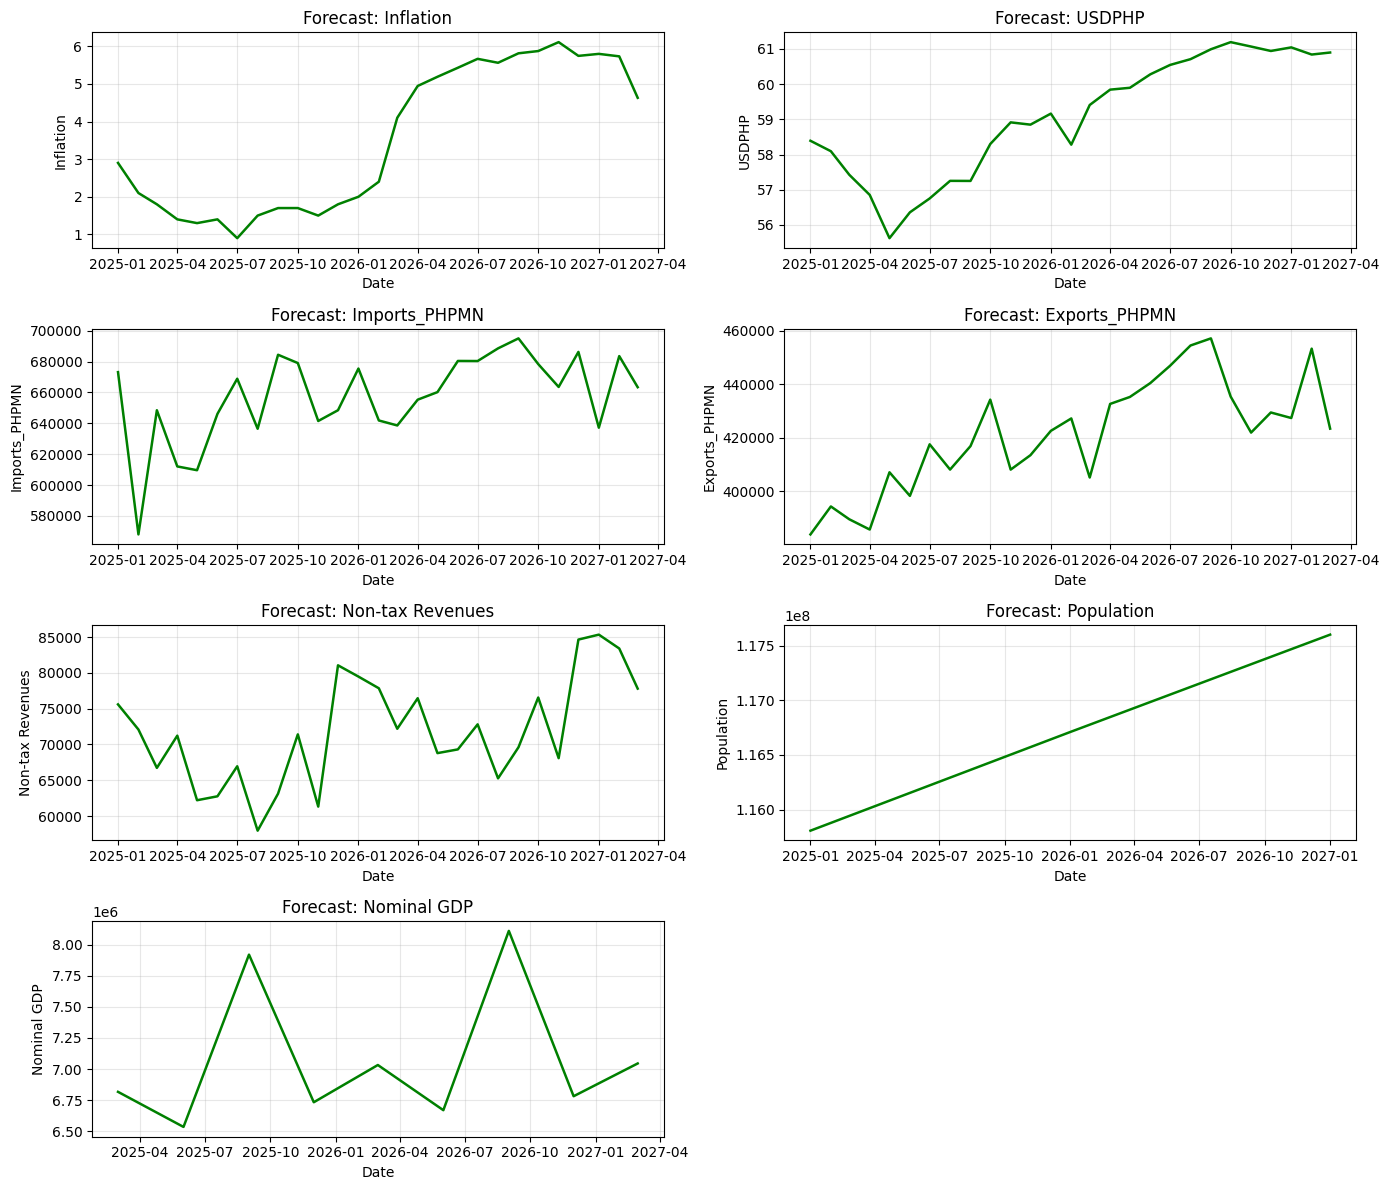

In [17]:
def plot_forecast_df(forecast_df, columns=None, ncols=2, figsize=(14, 10), dropna_each_series=True):
    """Plot forecast columns from a dataframe with a DatetimeIndex.

    Parameters
    ----------
    forecast_df : pd.DataFrame
        Dataframe containing forecast series.
    columns : list[str] | None
        Columns to plot. If None, all columns are plotted.
    ncols : int
        Number of subplot columns.
    figsize : tuple
        Figure size.
    dropna_each_series : bool
        If True, each subplot drops NaN values before plotting.
    """
    if not isinstance(forecast_df, pd.DataFrame):
        raise TypeError("forecast_df must be a pandas DataFrame.")
    if forecast_df.empty:
        raise ValueError("forecast_df is empty.")

    plot_cols = list(forecast_df.columns) if columns is None else [c for c in columns if c in forecast_df.columns]
    if not plot_cols:
        raise ValueError("No valid columns found to plot.")

    data = forecast_df.copy()
    data.index = pd.to_datetime(data.index)

    n = len(plot_cols)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    axes = axes.flatten()

    for i, col in enumerate(plot_cols):
        ax = axes[i]
        s = data[col].copy()
        if dropna_each_series:
            s = s.dropna()

        ax.plot(s.index, s.values, color="green", linewidth=1.8)
        ax.set_title(f"Forecast: {col}")
        ax.set_xlabel("Date")
        ax.set_ylabel(col)
        ax.grid(True, alpha=0.3)

    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


# Example usage on your combined forecast dataframe:
plot_forecast_df(all_predictions_2025_2026, ncols=2, figsize=(14, 12))